In [8]:
# 그럼 첫번째 레슨 : 라이브러리 불러오기

#필요한 딥러닝 관련 라이브러리를 불러옵니다.

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [9]:
# 🗂️ Step 2: 데이터 불러오기

#CIFAR-10 데이터셋을 불러오고, 학습용/테스트용으로 분리합니다.

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()


## 과제1. 데이터의 구조를 살펴보세요. 사이즈는?

In [10]:
# 여기에서 확인해 보세요.

print(train_images.shape, train_labels.shape, test_images.shape, test_labels.shape)
# (50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


학습 이미지는 50,000장, 테스트 이미지는 10,000장으로 이루어져 있음 \
각 이미지 크기는 32x32 픽셀이며 RGB의 3채널로 되어 있음. \
이미지 각각에 해당하는 정답 라벨이 주어져 있음 (0~9)

In [11]:
# 🏷️ Step 3: 클래스 이름 정의

#CIFAR-10의 라벨은 숫자로 되어 있으므로, 사람이 이해할 수 있도록 이름을 부여합니다.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 과제2. 아래 코드의 빈칸을 채워 CNN 모델을 완성해보세요. 
#### layer나 패딩 혹은 drop out, batch normalization을 추가해 가며 모델의 정확도 변화를 보는 것도 좋습니다.

In [24]:
# 🧱 Step 4: CNN 모델 구성
# Convolution → MaxPooling → Flatten → Dense 구조로 CNN을 설계합니다.
# 아래의 빈칸 (___)을 채워 모델을 완성해보세요.

model = models.Sequential()



## 첫 번째 합성곱 레이어
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # TODO: 커널 개수 설정 -> 32
# 출력 shape: (30, 30, 32)
model.add(layers.BatchNormalization())  # 출력 shape: (30, 30, 32)

## 첫 번째 풀링 레이어
model.add(layers.MaxPooling2D((2,2)))  # TODO: 풀링 크기 설정 -> 그대로 (일반적)
# 출력 shape: (15, 15, 32)

model.add(layers.Dropout(0.3)) 


## 두 번째 합성곱 레이어
model.add(layers.Conv2D(64, (3, 3), activation='relu'))  # TODO: 커널 크기 설정 -> (3,3) 
# 출력 shape: (13, 13, 32)
model.add(layers.BatchNormalization())  # 출력 shape: (13, 13, 64)

## 두 번째 풀링 레이어
model.add(layers.MaxPooling2D((2, 2)))
# 출력 shape: (6, 6, 64)

model.add(layers.Dropout(0.3))


## 세 번째 합성곱 레이어
model.add(layers.Conv2D(128, (3, 3), activation='relu'))  # TODO: 커널 개수 설정 -> 128
# 출력 shape: (4, 4, 128)
model.add(layers.BatchNormalization())  # 출력 shape: (4, 4, 128)

model.add(layers.Dropout(0.3)) 

# Flatten + Fully Connected Layer
model.add(layers.Flatten())  # 출력 shape: (2048,)
model.add(layers.Dense(256))  # TODO: 은닉층 유닛 수 설정 -> 128
model.add(layers.Dropout(0.7))  
model.add(layers.Dense(10))  # 출력층: CIFAR-10은 클래스가 10개

## 자신이 채운 코드를 기반으로 각 레이어별 Feature Map 크기를 계산해 보세요. 
(padding은 디폴트로 없습니다.)

첫 번째 합성곱 레이어 출력 Feature Map 크기 : (30, 30, 32) \
→ 입력 (32, 32, 3)에서 커널 크기 (3, 3), 스트라이드 1, 패딩 없음 \
→ (32 - 3) // 1 + 1

배치 정규화 레이어 출력 Feature Map 크기 : (30, 30, 32) \
→ 입력과 동일한 크기 유지

첫 번째 풀링 레이어 출력 Feature Map 크기 : (15, 15, 32) \
→ (2,2) MaxPooling으로 절반으로 줄어듦

두 번째 합성곱 레이어 출력 Feature Map 크기 : (13, 13, 64) \
→ (15 - 3) // 1 + 1

배치 정규화 레이어 출력 Feature Map 크기 : (13, 13, 64) \
→ 입력과 동일한 크기 유지

두 번째 풀링 레이어 출력 Feature Map 크기 : (6, 6, 64) \
→ 마찬가지로 절반으로 줄어듦

세 번째 합성곱 레이어 출력 Feature Map 크기 : (4, 4, 128) 
→ (6 - 3) // 1 + 1

배치 정규화 레이어 출력 Feature Map 크기 : (4, 4, 128) \
→ 입력과 동일한 크기 유지

Flatten 레이어 출력 Feature Map 크기 : 2048 \
→ 4×4×128 = 2048

Dense 레이어 (은닉층) 출력 Feature Map 크기 : 256

Dropout 레이어 출력 Feature Map 크기 : 256 \
→ 변화 없음 (뉴런 수 감소)

출력층 (Dense) 출력 Feature Map 크기 : 10

In [25]:
# ⚙️ Step 5: 모델 컴파일

#모델을 학습할 수 있도록 컴파일합니다. 손실 함수, 최적화 방법, 평가지표를 설정합니다.

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

Epoch 1/30
1563/1563 [==============================] - 29s 17ms/step - loss: 2.4582 - accuracy: 0.3610 - val_loss: 1.4138 - val_accuracy: 0.4966
Epoch 2/30
1563/1563 [==============================] - 26s 17ms/step - loss: 1.4453 - accuracy: 0.4874 - val_loss: 1.7799 - val_accuracy: 0.4492
Epoch 3/30
1563/1563 [==============================] - 27s 17ms/step - loss: 1.2879 - accuracy: 0.5501 - val_loss: 1.1982 - val_accuracy: 0.5888
Epoch 4/30
1563/1563 [==============================] - 27s 17ms/step - loss: 1.1732 - accuracy: 0.5934 - val_loss: 1.0567 - val_accuracy: 0.6378
Epoch 5/30
1563/1563 [==============================] - 27s 17ms/step - loss: 1.0812 - accuracy: 0.6218 - val_loss: 1.1007 - val_accuracy: 0.6184
Epoch 6/30
1563/1563 [==============================] - 28s 18ms/step - loss: 1.0167 - accuracy: 0.6480 - val_loss: 0.8257 - val_accuracy: 0.7105
Epoch 7/30
1563/1563 [==============================] - 29s 18ms/step - loss: 0.9742 - accuracy: 0.6620 - val_loss: 1.4702 -

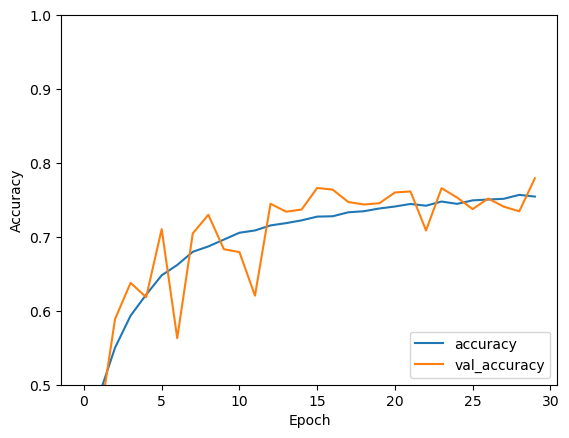

In [26]:
# 🔥 Step 6: 모델 학습 및 성능 평가

history = model.fit(train_images, train_labels, epochs=30,
                    validation_data=(test_images, test_labels))
#모델 성능 평가
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,
                                     test_labels,
                                     verbose=2)


In [50]:
print('Test Accuracy is',test_acc)

Test Accuracy is 0.7792999744415283


## 과제3. 직접사용해 보기. 이미지를 로드하고 cifar-10의 사이즈로 리사이즈

1/1 [==============================] - 0s 210ms/step


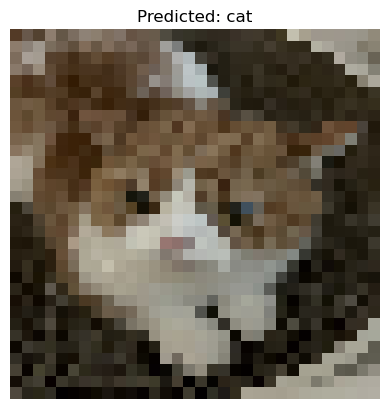

In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 새 이미지를 로드하고 모델 예측 수행
def predict_new_image(image_path, model, class_names):
    # 이미지 로드 및 전처리
    img = image.load_img(image_path, target_size=(32, 32))  # CIFAR-10 크기로 리사이즈 빈칸채우기 -> (32, 32)
    img_array = image.img_to_array(img)  # 이미지를 배열로 변환
    img_array = np.expand_dims(img_array, axis=0)  # 배치를 위해 차원 추가
    img_array = img_array / 255.0  # 정규화 

    # 예측 수행
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)  # 가장 높은 확률의 클래스 인덱스
    class_name = class_names[predicted_class]  # 클래스 이름

    # 결과 출력
    plt.imshow(img)
    plt.title(f"Predicted: {class_name}")
    plt.axis('off')
    plt.show()

# 사용 예시
image_path = 'buzzi.jpg'
# 예측할 이미지의 경로 절대경로를 입력하면 됩니다. 뭔가 자신의 얼굴사진을 넣어보면 재미있는일이...
predict_new_image(image_path, model, class_names)


## 왜 255.0으로 나누었을까요? 이미지 전처리에 대한 지식이니 조사해보세요.

Answer: 이미지의 픽셀 값이 0과 255 사이의 정수이기 때문에 255.0으로 나눠서 픽셀 값을 0과 1로 정규화를 하는 과정입니다.

## 과제4. CNN의 inductive bias에 대해서 조사를 해보고 생각해 봅시다.
### CNN은 왜 이미지 처리에 좋을까요? 이미지 말고도 CNN을 잘 쓸 수 있는데는 어디일까요?

1. Receptive field \
→ 입력 이미지의 일부를 통해 학습하기 때문에 주변 정보를 더 잘 포착하고 공간 구조를 더 잘 반영합니다. 
2. Parameter sharing \
→ 같은 필터를 이미지에 여러 위치에 동일하게 적용해서 연산량을 줄이고 주요 특징을 더 효율적이고 반복적으로 감지할 수 있습니다. 
3. Sparse Interation \
→ DNN처럼 모든 뉴런을 연결하는 것이 아니라 일부 위치만 보게 하기 때문에 연산 효율을 높일 수 있습니다. 

## 과제 1

- OR 게이트 학습 및 시각화 (ANN)

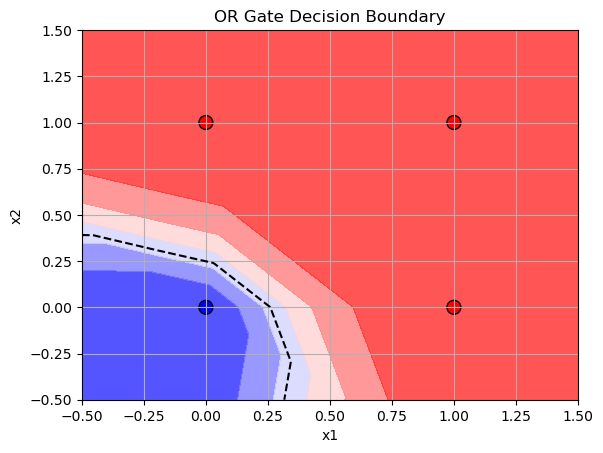

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# (선택) 시드 고정: 항상 같은 결과 보장
tf.random.set_seed(42)

# 1. 데이터: OR 게이트
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [1]])

# 2. 모델 구성 (은닉층 1개)
model = Sequential()
model.add(Dense(4, input_dim=2, activation='relu'))  # 은닉층
model.add(Dense(1, activation='sigmoid'))            # 출력층

model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(X, y, epochs=3000, verbose=0)

# 3. 시각화 함수
def plot_decision_boundary(model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0).reshape(xx.shape)

    plt.contourf(xx, yy, preds, cmap='bwr', alpha=0.8)  # cmap 수정됨
    plt.contour(xx, yy, preds, levels=[0.5], colors='k', linestyles='--')
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='bwr', edgecolors='k', s=100)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("OR Gate Decision Boundary")
    plt.grid(True)
    plt.show()

# 4. 시각화 실행
plot_decision_boundary(model, X, y)


단층 인공신경망을 사용해 OR 게이트를 분류하고, 결과를 시각화했습니다. 입력값은 두 개이며, (0,0)은 0으로, 나머지 (0,1), (1,0), (1,1)은 1로 분류되도록 학습했습니다.

모델은 은닉층 하나로 구성되어 있고, 이 은닉층에는 노드 4개를 사용했습니다. 활성화 함수는 ReLU를 적용했고, 출력층에서는 sigmoid 함수를 사용해 0과 1 사이의 확률 값을 출력하도록 했습니다. 손실 함수는 binary crossentropy를 사용했으며, 학습은 총 3000번 반복했습니다. 학습을 반복할 때마다 결과가 달라지지 않도록 시드를 고정했습니다.

학습된 모델의 결과를 시각화한 그래프에서는 (0,0)만 파란색 영역에, 나머지 세 점은 붉은색 영역에 위치해 있는 걸 확인할 수 있습니다. 모델이 OR 논리를 정확하게 학습했으며, 경계선도 OR 구조에 맞게 잘 형성되었다는 것을 보여줍니다.

- XOR 게이트 학습 시도 및 한계 시각화 (ANN)

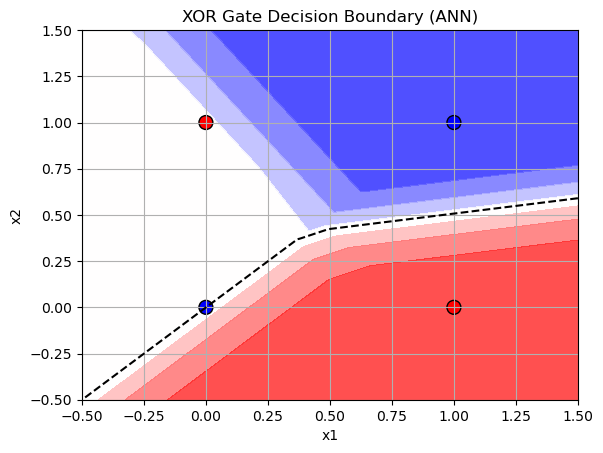

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# 시드 고정 (일관된 결과 위해)
tf.random.set_seed(42)

# 1. 데이터: XOR 게이트
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# 2. 모델: 은닉층 1개짜리 ANN
model = Sequential()
model.add(Dense(4, input_dim=2, activation='relu'))  # 은닉층 1개
model.add(Dense(1, activation='sigmoid'))            # 출력층

model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(X, y, epochs=3000, verbose=0)

# 3. 시각화 함수
def plot_decision_boundary(model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0).reshape(xx.shape)

    plt.contourf(xx, yy, preds, cmap='bwr', alpha=0.8)
    plt.contour(xx, yy, preds, levels=[0.5], colors='k', linestyles='--')
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='bwr', edgecolors='k', s=100)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("XOR Gate Decision Boundary (ANN)")
    plt.grid(True)
    plt.show()

# 4. 시각화 실행
plot_decision_boundary(model, X, y)


다층 인공신경망이 아닌 단층 구조(은닉층 1개)로 XOR 게이트를 분류해보고 시각화해봤습니다. 입력은 두 개의 값이고, XOR의 특성에 따라 (0,0)과 (1,1)은 0으로, (0,1)과 (1,0)은 1로 분류되어야 합니다. 모델은 은닉층 하나로 구성되어 있으며, 노드는 4개이고 활성화 함수는 ReLU를 사용했습니다. 출력층은 sigmoid로 설정해 0~1 사이 확률 값이 출력되도록 했습니다.

3000번의 학습을 진행했지만 시각화된 결과를 보면, 파란 영역과 빨간 영역이 XOR 특성대로 완전히 분리되지 않는 모습이었습니다. 이는 은닉층이 한 개뿐인 ANN 구조로는 비선형 문제인 XOR 패턴을 완벽히 학습하기 어렵다는 것을 보여줍니다. 이를 통해 XOR 문제를 풀기 위해선 더 깊은 구조의 DNN이 필요하다는 것을 확인할 수 있습니다.

- XOR 게이트 학습 및 시각화 (DNN)

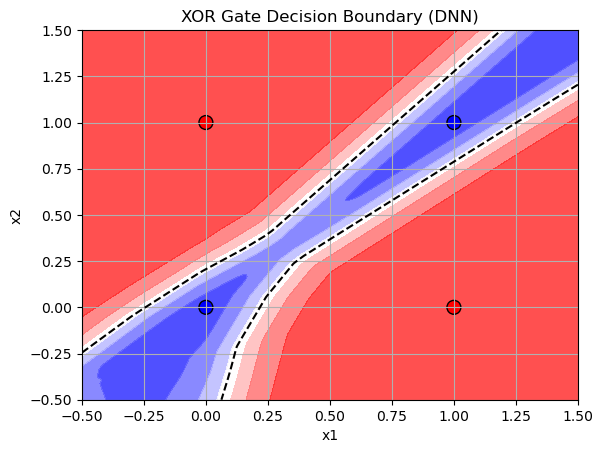

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# 시드 고정
tf.random.set_seed(42)

# 1. XOR 데이터
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# 2. DNN 모델: 은닉층 2개 이상
model = Sequential()
model.add(Dense(16, input_dim=2, activation='relu'))  # 은닉층 1
model.add(Dense(16, activation='relu'))               # 은닉층 2
model.add(Dense(8, activation='relu'))                # 은닉층 3
model.add(Dense(4, activation='relu'))                # 은닉층 4
model.add(Dense(1, activation='sigmoid'))             # 출력층

model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(X, y, epochs=3000, verbose=0)

# 3. 시각화 함수
def plot_decision_boundary(model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0).reshape(xx.shape)

    plt.contourf(xx, yy, preds, cmap='bwr', alpha=0.8)
    plt.contour(xx, yy, preds, levels=[0.5], colors='k', linestyles='--')
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='bwr', edgecolors='k', s=100)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("XOR Gate Decision Boundary (DNN)")
    plt.grid(True)
    plt.show()

# 4. 시각화
plot_decision_boundary(model, X, y)


마지막으로 다층의 인공신경망인 DNN을 이용하여 XOR 게이트 분류를 시도하고 결과를 시각화하였습니다. XOR 게이트는 입력값 (0,0)과 (1,1)에 대해 출력이 0, (0,1)과 (1,0)에 대해 출력이 1이 되는 비선형 문제입니다. XOR의 특성으로 인해 단층 신경망으로는 정확한 분리가 어렵습니다.

은닉층을 한 개가 아닌 4개로 구성하고, 각각 16개, 16개, 8개, 4개의 노드를 사용했습니다. 활성화 함수는 모두 ReLU를 적용하였습니다. 출력층은 sigmoid를 사용하여 결과가 0에서 1 사이의 확률로 출력되도록 하였습니다.

3000번의 학습을 거친 결과, (0,1)과 (1,0)의 데이터는 빨간 영역에, (0,0)과 (1,1)은 파란 영역에 안정적으로 분리된 것을 확인할 수 있었습니다. 이는 여러 은닉층을 활용하여 XOR처럼 비선형적인 문제를 해결할 수 있음을 보여줍니다.